# MZI Delay Arm -- Dense delta_L_um Sweep at radius_um=2.5 (Stage-2 Library)

This notebook does **not** modify `03_mzi_arm.ipynb` or `11_mzi_arm_dense_sweep.ipynb`.
It builds a NEW arm-length FDTD library at `radius_um=2.5` (the bend radius the MUX4
tree's stage2_up/stage2_down branches use, per `circuits/wdm_mux4_sax.ipynb` --
distinct from stage 1's `radius_um=5.0`), for use by
`pic_toolkit.optimization.arm_library.load_arm_length_library(radius_um=2.5)`'s
length-axis S-parameter interpolation in the stage-2 adjoint optimization
(see `docs/simulation_settings_record.md`'s "`circuits/` MUX2 (N=4 lattice) geometry-optimization program" section; that optimization effort is now paused).

Only 2 points currently exist at this radius
(`data/sparams/mzi_arm/sweep_r2.5/`: `delta_L_um` = 7.5 and 7.6401287108158605,
saved by `wdm_mux4_sax.ipynb` for its own fixed-point FDTD comparison) -- far too
sparse for gradient-based search. This notebook densifies the range from just above
the geometry's floor (6.632um at this radius) through a generous window around both
stage-2 targets, saved to a **new sibling directory**,
`data/sparams/mzi_arm/sweep_r2p5_dense/`.

**Do not use "Run All."** Each point is a full 2-direction FDTD simulation; run cells
one at a time and expect the full sweep to take a long time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pic_toolkit.meep_sim import mzi_arm
from pic_toolkit import sparams, sweep, style

style.apply_style()
%matplotlib inline

params = dict(mzi_arm.DEFAULT_PARAMS)
params["radius_um"] = 2.5  # stage-2 geometry -- DEFAULT_PARAMS's own radius_um=5.0 is stage-1's
params


{'wg_width_um': 0.5,
 'core_index': 2.7,
 'clad_index': 1.44,
 'polarization': 'TE',
 'wl_min_um': 1.3,
 'wl_max_um': 1.4,
 'resolution': 40,
 'dpml_um': 1.0,
 'radius_um': 2.5,
 'bend_type': 'euler',
 'extra_straight_um': 0.864,
 'lead_len_um': 3.0,
 'n_freq': 21,
 'margin_um': 1.5,
 'port_offset_um': 1.0,
 'source_offset_um': 0.5}

## New target grid

Floor at `radius_um=2.5` (`bend_type="euler"`) is ~6.632um -- all targets below are
safely above it. Spans the existing 7.5/7.64um points (kept, not re-simulated) up
through 20um, giving the stage-2 Adam optimizer generous search room.

In [2]:
EXISTING_DELTA_L_UM = [7.5, 7.6401287108158605]  # already in data/sparams/mzi_arm/sweep_r2.5/
NEW_DELTA_L_UM = [7.0, 8.0, 9.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0]

NEW_EXTRA_STRAIGHT_UM = [mzi_arm.extra_straight_um_for_delta_L(dl, params) for dl in NEW_DELTA_L_UM]
print(list(zip(NEW_DELTA_L_UM, [round(e, 4) for e in NEW_EXTRA_STRAIGHT_UM])))


[(7.0, 0.184), (8.0, 0.684), (9.0, 1.184), (10.0, 1.684), (12.0, 2.684), (14.0, 3.684), (16.0, 4.684), (18.0, 5.684), (20.0, 6.684)]


## Run the sweep

Same loose sweep tolerances as the radius=5.0 sweep -- same geometry family, just a
different radius/denser sampling.

> **STOP -- this cell runs real FDTD simulations (9 points, each a 2-direction run).
> Expect a long runtime. Run it, then wait.**

In [3]:
SWEEP_CHECK_KWARGS = dict(energy_tol=0.15, reciprocity_tol=0.15, passivity_tol=0.05, max_loss_fraction=0.30)

sweep_rows = sweep.grid_sweep(
    simulate_fn=mzi_arm.simulate_baseline,
    base_params=params,
    param_grid={"extra_straight_um": NEW_EXTRA_STRAIGHT_UM},
    artifact_dir=Path("../data/sparams/mzi_arm/sweep_r2p5_dense"),
    component_name="mzi_arm",
    check_kwargs=SWEEP_CHECK_KWARGS,
)
n_passed = sum(row["validation_passed"] for row in sweep_rows)
print(f"radius=2.5 dense delta_L sweep: {n_passed}/{len(sweep_rows)} points within the (loose) sweep tolerance")
sweep.save_manifest(sweep_rows, Path("../data/sparams/mzi_arm/sweep_r2p5_dense/manifest.csv"))


[1/9  11%] running mzi_arm (extra_straight_um=0.18399999999999928) ...


[2/9  22%] running mzi_arm (extra_straight_um=0.6839999999999993) ...


[3/9  33%] running mzi_arm (extra_straight_um=1.1839999999999993) ...


[4/9  44%] running mzi_arm (extra_straight_um=1.6839999999999993) ...


[5/9  55%] running mzi_arm (extra_straight_um=2.6839999999999993) ...


[6/9  66%] running mzi_arm (extra_straight_um=3.6839999999999993) ...


[7/9  77%] running mzi_arm (extra_straight_um=4.683999999999999) ...


[8/9  88%] running mzi_arm (extra_straight_um=5.683999999999999) ...


[9/9  100%] running mzi_arm (extra_straight_um=6.683999999999999) ...


radius=2.5 dense delta_L sweep: 9/9 points within the (loose) sweep tolerance


## Visualize: transmission and loss across the combined (existing + new) grid

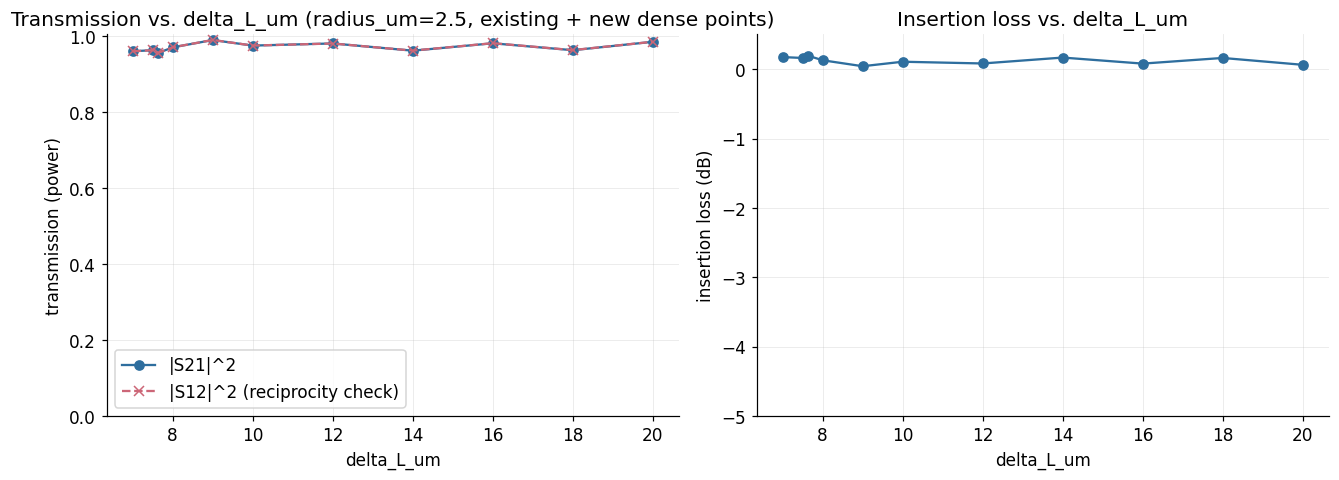

In [4]:
ALL_DELTA_L_UM = sorted(EXISTING_DELTA_L_UM + NEW_DELTA_L_UM)

def _artifact_dir_and_extra(delta_L_um):
    if delta_L_um in EXISTING_DELTA_L_UM:
        return Path("../data/sparams/mzi_arm/sweep_r2.5"), mzi_arm.extra_straight_um_for_delta_L(delta_L_um, params)
    return Path("../data/sparams/mzi_arm/sweep_r2p5_dense"), mzi_arm.extra_straight_um_for_delta_L(delta_L_um, params)

delta_L_achieved, s21_center, s12_center, loss_db_center = [], [], [], []
for dl_target in ALL_DELTA_L_UM:
    art_dir, extra = _artifact_dir_and_extra(dl_target)
    tag = f"extra_straight{extra}"
    a = sparams.load_artifact(art_dir / f"mzi_arm_{tag}")
    mid = len(a.wavelengths_um) // 2
    s21, s12 = a.s_matrix["21"][mid], a.s_matrix["12"][mid]
    delta_L_achieved.append(mzi_arm.delta_L_um_from_extra(extra, params))
    s21_center.append(np.abs(s21) ** 2)
    s12_center.append(np.abs(s12) ** 2)
    loss_db_center.append(-10 * np.log10(np.abs(s21) ** 2))

delta_L_achieved = np.array(delta_L_achieved)

fig, (ax_t, ax_l) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_t.plot(delta_L_achieved, s21_center, "o-", color=style.COLOR_STEEL, label="|S21|^2")
ax_t.plot(delta_L_achieved, s12_center, "x--", color=style.COLOR_ROSE, label="|S12|^2 (reciprocity check)")
ax_t.set_xlabel("delta_L_um"); ax_t.set_ylabel("transmission (power)")
ax_t.set_title("Transmission vs. delta_L_um (radius_um=2.5, existing + new dense points)")
ax_t.set_ylim(0, 1.005); ax_t.legend()

ax_l.plot(delta_L_achieved, loss_db_center, "o-", color=style.COLOR_STEEL)
ax_l.set_xlabel("delta_L_um"); ax_l.set_ylabel("insertion loss (dB)")
ax_l.set_title("Insertion loss vs. delta_L_um")
ax_l.set_ylim(-5, 0.5)
fig.tight_layout()
plt.show()
